In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
cloverchen_causalpitfalls_benchmark_causal_data_neurips_2025_path = kagglehub.dataset_download('cloverchen/causalpitfalls-benchmark-causal-data-neurips-2025')

print('Data source import complete.')

## Data exploration

Here we import the data and explore each dataset and visualize the data.

In [ ]:
# Import library
import pandas as pd # load dataset
import seaborn as sns # visualize data

# Load causal_direction_iv dataset
data = pd.read_csv('/kaggle/input/datasets/cloverchen/causalpitfalls-benchmark-causal-data-neurips-2025/CausalPitfallsData/causal_direction_iv/causal_direction_iv_sem.csv')
data_ct = pd.read_csv('/kaggle/input/datasets/cloverchen/causalpitfalls-benchmark-causal-data-neurips-2025/CausalPitfallsData/causal_direction_iv/clinical_trial_sem.csv')
data_ecom = pd.read_csv('/kaggle/input/datasets/cloverchen/causalpitfalls-benchmark-causal-data-neurips-2025/CausalPitfallsData/causal_direction_iv/ecommerce_sem.csv')
data_env = pd.read_csv('/kaggle/input/datasets/cloverchen/causalpitfalls-benchmark-causal-data-neurips-2025/CausalPitfallsData/causal_direction_iv/environment_sem.csv')
data_mkt = pd.read_csv('/kaggle/input/datasets/cloverchen/causalpitfalls-benchmark-causal-data-neurips-2025/CausalPitfallsData/causal_direction_iv/marketing_sem.csv')

# Explore structure of causal direction IV
print(data.head())
print(data.columns)
# Visualize relationships
sns.pairplot(data)

   baseline_health  dosage_mg  drug_concentration  health_improvement
0         0.417022  23.032399           33.589587           23.614753
1         0.720324  45.593094           69.246066           51.456062
2         0.000114  40.068309           60.868536           41.340428
3         0.302333  40.505284           62.482962           46.217086
4         0.146756  28.779161           42.263672           29.639678
Index(['baseline_health', 'dosage_mg', 'drug_concentration',
       'health_improvement'],
      dtype='object')


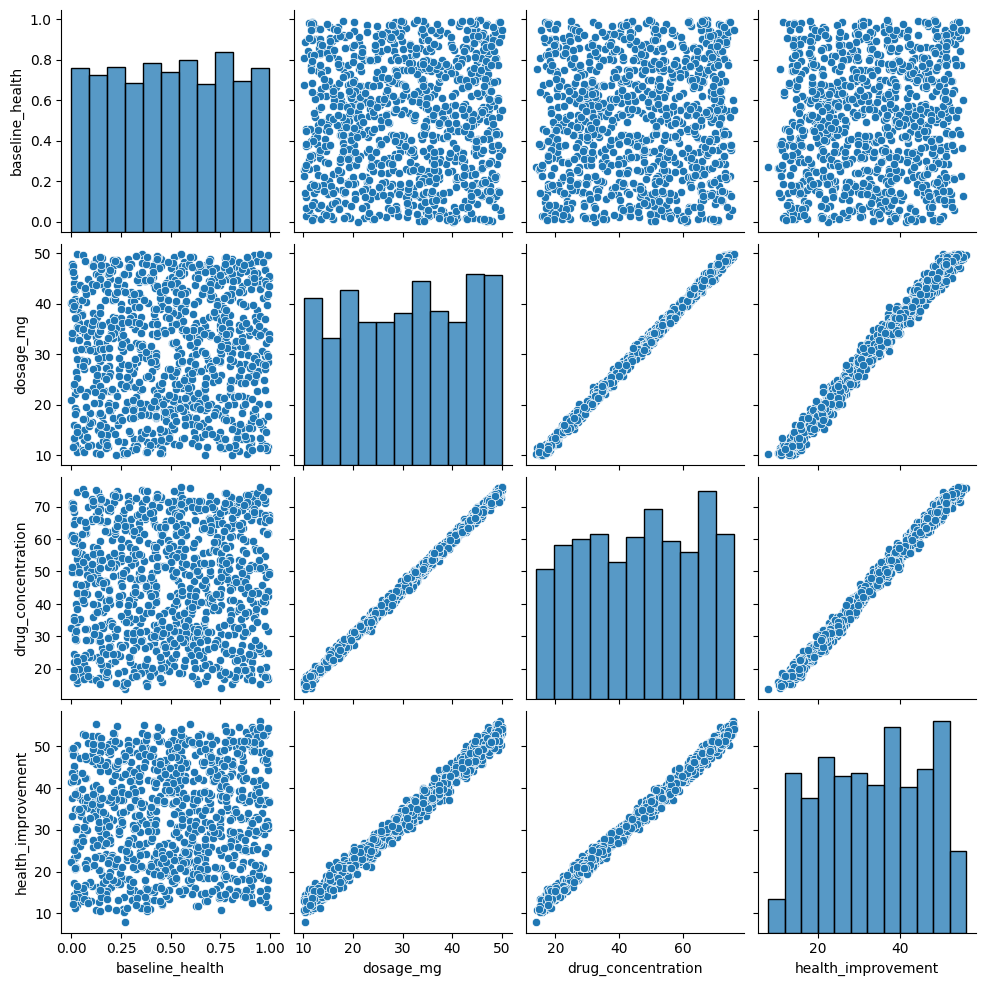

In [ ]:
# Dataset: Clinical trial
print(data_ct.head())
print(data_ct.columns)
sns.pairplot(data_ct)

         age        income     visits   purchases
0  43.794235  83359.224370  34.442595  875.697981
1  51.613900  30905.732609  42.647868  361.745160
2  46.329879  72824.357627  38.013870  775.654642
3  43.609510  93789.335185  35.796097  982.040928
4  37.911776  33957.788882  31.152911  376.626669
Index(['age', 'income', 'visits', 'purchases'], dtype='object')


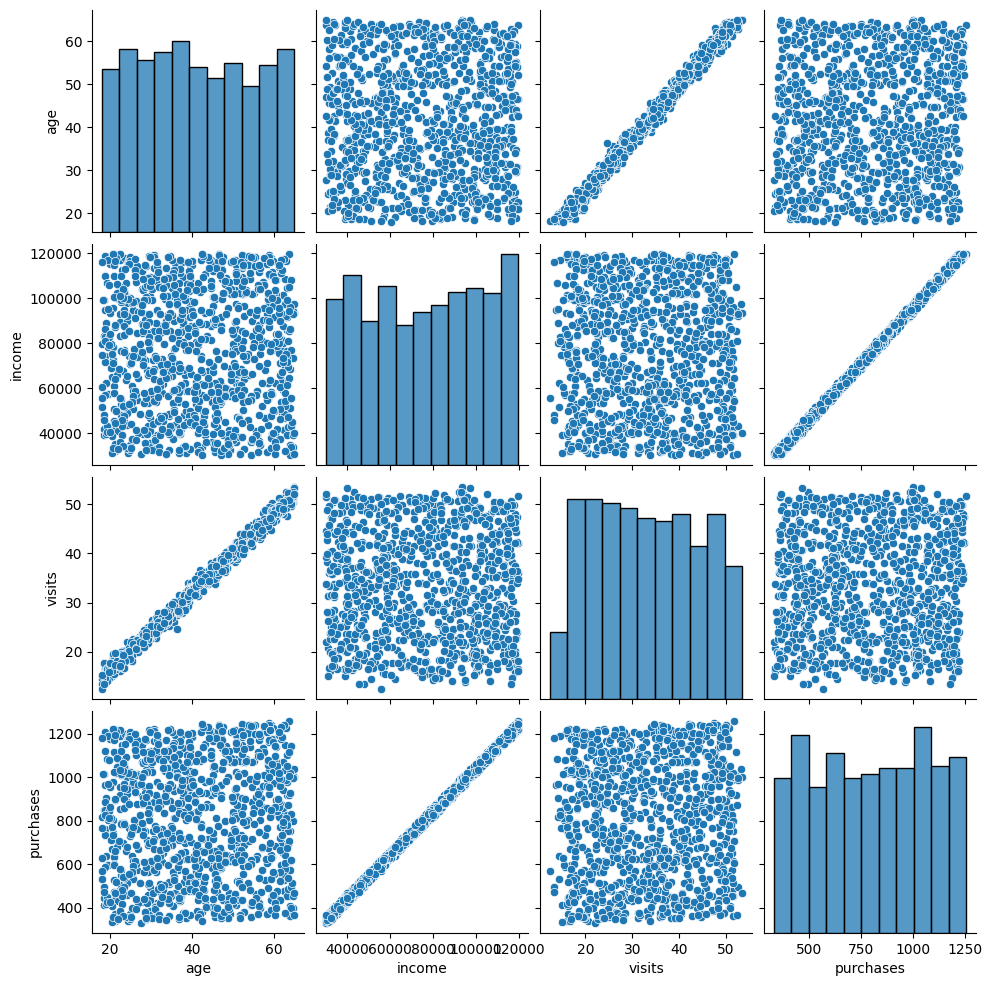

In [ ]:
# Dataset: ecommerce
print(data_ecom.head())
print(data_ecom.columns)
sns.pairplot(data_ecom)

   rainfall_mm  fertilizer_kg  soil_quality  crop_yield
0   110.159581      92.177844     53.071992  153.563194
1   141.629565     100.313369     70.893930  176.144531
2    58.180948      97.633148     29.089590  138.789607
3   102.165521     134.826594     49.824619  204.196801
4   178.589391     148.315103     89.579545  250.468642
Index(['rainfall_mm', 'fertilizer_kg', 'soil_quality', 'crop_yield'], dtype='object')


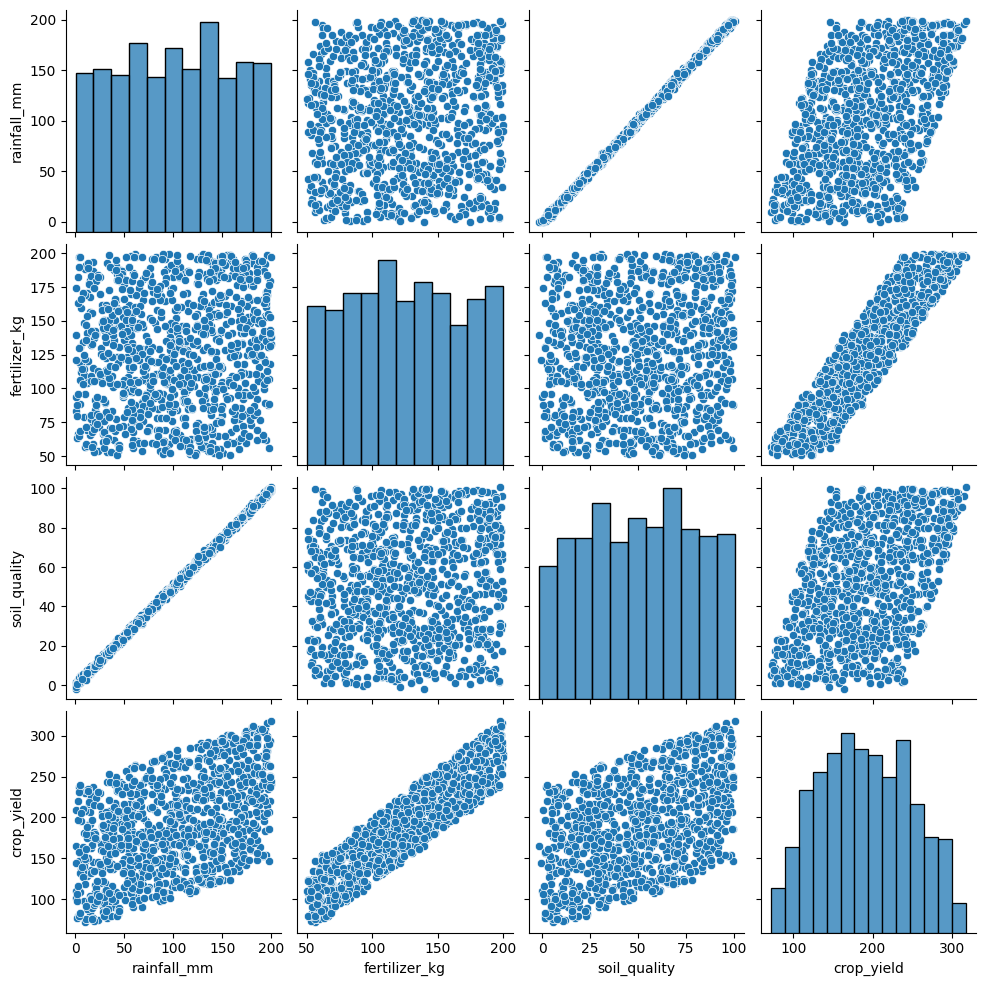

In [ ]:
# Dataset: environment
print(data_env.head())
print(data_env.columns)
sns.pairplot(data_env)

   ad_spend_k  promo_spend_k  brand_awareness      sales
0   43.599490      31.092130        39.605595  65.611068
1    2.592623      28.278951         2.118981  37.140109
2   54.966248       7.633548        49.905563  39.997305
3   43.532239      40.671842        39.919487  76.809692
4   42.036780      49.173099        36.592662  85.053314
Index(['ad_spend_k', 'promo_spend_k', 'brand_awareness', 'sales'], dtype='object')


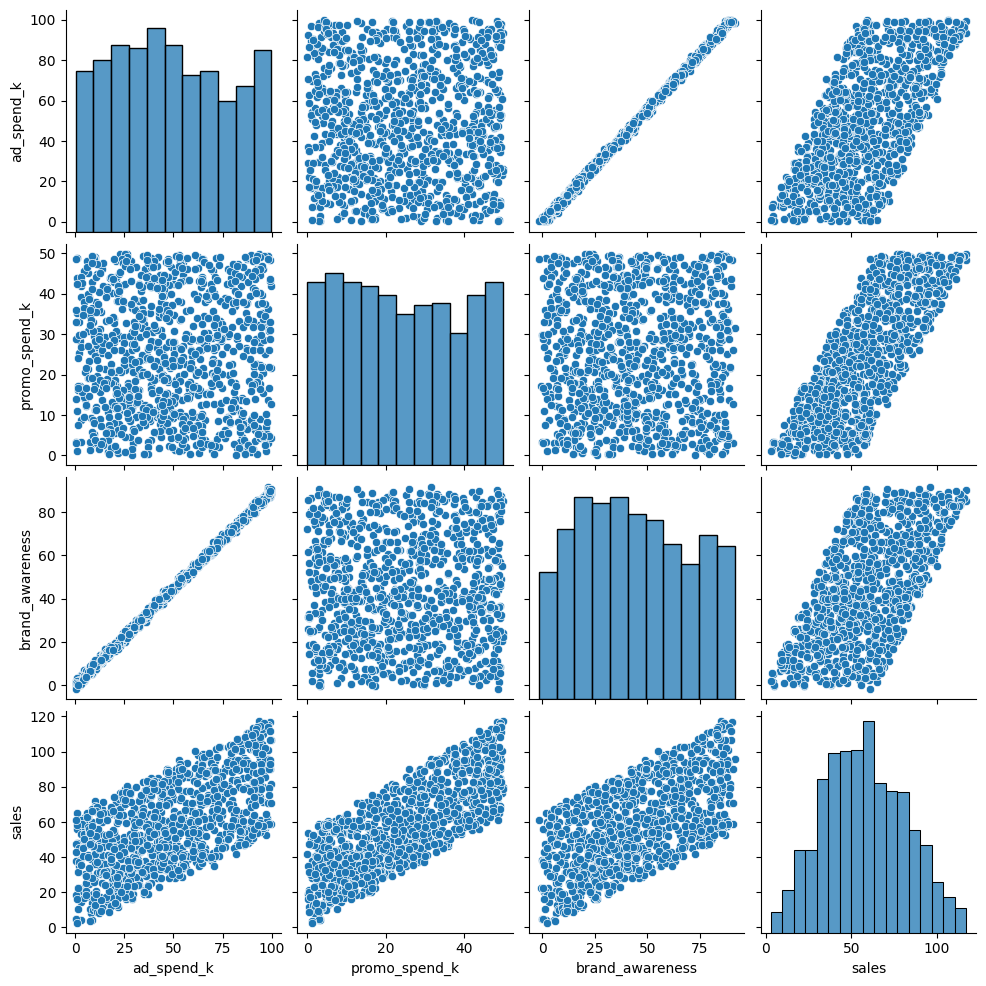

In [ ]:
# Dataset: marketing
print(data_mkt.head())
print(data_mkt.columns)
sns.pairplot(data_mkt)

## Approach to the dataset

**Overview:**

1. 2SLS for for causal direction identification
2. Evaluation results on all 5 datasets with accuracy scores
3. Comparison of different IV methods (2SLS vs control function vs ML-based)
4. Visualizations showing how Z relates to X and Y in each direction
5. Discussion on when IV works and when it fails

**Detail:**

We first tested basic IV methods on the "causal_direction_iv" data as a pilot batch with methods 2SLS and statsmodels IV2SLS for causal direction identification.

Secondly, we tested causal direction in both directions: (1) testing X_1 -> X_2 using Z_1 as IV for X_1; (2) testing X_2 -> X_1 using Z_1 as IV for X_2; then we compared which direction is supported.

Lastly, we tested on all 5 datasets and evaluated and calculated accuracy compared to ground truth.

Advanced methods such as ML-based IV methods and DeepIV for non-linear relationships will be tested after we compare and test on all 5 datasets.


#### 1. Basic IV Method

Here we tested basic IV methods on the "causal_direction_iv" data as a pilot batch with methods 2SLS and statsmodels IV2SLS.

In [ ]:
from sklearn.linear_model import LinearRegression

# Stage 1: Predict X_1 using Z_1
stage1 = LinearRegression().fit(data[['Z_1']], data['X_1'])
X1_hat = stage1.predict(data[['Z_1']])

# Stage 2: Regress X_2 on X1_hat
stage2 = LinearRegression().fit(X1_hat.reshape(-1,1), data['X_2'])
causal_effect = stage2.coef_[0]

print(f"Causal effect of X_1 on X_2: {causal_effect}")

Causal effect of X_1 on X_2: 0.9043926490044419
